In [2]:
from globals.utils import Log
from processing import utils
import importlib
subjects = None # list of subject names or None for all subjects 

### Data Preprocessing

In [160]:
#/ convert raw data to processed npy files and save a dataframe to disk
from processing import conversion

conversion.cleanup_data() # cleans the original data directory and prepares for processing (only needs to be run once if data is raw)
conversion.process_subjects(overwrite=False) # processes each subject and export npy files
conversion.save_dataframe(overwrite=True) # save the formatted df to disk for efficient access

utils.get_dataframe().head()


Processing data for periklis
	Successfully processed data for periklis

Processing data for polemarchakis
	Successfully processed data for polemarchakis

Processing data for nick
	Processing 10.1.mat (MVC: 10, Trial: 1)...
	Successfully processed data for nick

Processing data for nikos
	Successfully processed data for nikos

Processing data for nastos-jr
	Successfully processed data for nastos-jr

Processing data for dim_tselios
	Processing 20.2.mat (MVC: 20, Trial: 2)...
	Successfully processed data for dim_tselios

Processing data for iatroudelis
	Successfully processed data for iatroudelis

Processing data for dwrotheos
	Successfully processed data for dwrotheos

Processing data for malidakis
	Successfully processed data for malidakis

Processing data for anestis
	Successfully processed data for anestis

Processing data for manos
	Successfully processed data for manos

Processing data for leonidas
	Successfully processed data for leonidas

Processing data for thanasis
	Successfull

,subject,mvc_level,trial_number,neuron_data,force_data
0,periklis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392304244, 0.012200930784608..."
1,periklis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.006100465392304244, 0.0, -0.01830..."
2,periklis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784608488, -0.006100465..."
3,periklis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.03660279235382191, -0.024401861569216..."
4,periklis,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784608488, 0.0183013961769127..."


In [161]:
#/ sanitize and manually check the data and save it to disk
from processing.sanitizer import Sanitizer

sanitizer = Sanitizer(df=utils.get_dataframe(subjects=subjects))
sanitizer.sanitize() #/ automatically sanitizes the data and saves it to disk, should be followed up with a manual check of the sanitized data

Computing global statistics...
	Average max activation distance: 4703.531791907514
	Max force data length: 101515
	Max number of neurons: 33
	Max number of activations: 101515
Global statistics computed.
Purging entries with insufficient neuron data...
Purged 36 entries with insufficient neuron data. 310 entries remaining.
Purging entries with inconsistent neuron data...
Purged 3 entries with inconsistent firing distances
Sanitized dataset saved to processing/data/dataset.pkl
Sanitized dataset contains 307 entries after sanitization.


,subject,mvc_level,trial_number,neuron_data,force_data
0,periklis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.08540651549225231, 0.11590884245376998, 0.1..."
1,periklis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.06100465392303889, 0.04880372313843395, 0.0..."
2,periklis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.07320558470764738, 0.018301396176912732, 0...."
3,periklis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.04880372313843395, 0.036602792353825464, 0...."
4,periklis,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.06710511931534313, 0.042703257746126155, 0...."
...,...,...,...,...,...
302,nastos-sr,40,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[3.263748984882561, 3.2698494502748616, 3.2637..."
303,nastos-sr,40,3,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.006100465392300691, 0.01830139617690918, 0...."
304,nastos-sr,60,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[4.483842063343332, 4.483842063343332, 4.48384..."
305,nastos-sr,60,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[6.545799365942024, 6.545799365942024, 6.55800..."


In [10]:
df = utils.get_dataframe()
Log.info(f"Total number of samples: {len(df)}")
df


Total number of samples: 234


,subject,mvc_level,trial_number,neuron_data,force_data
0,periklis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.07320558470764738, 0.018301396176912732, 0...."
1,periklis,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.06710511931534313, 0.042703257746126155, 0...."
2,periklis,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.2562195464767605, 0.244018615692152, 0.2623..."
3,periklis,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.006100465392304244, 0.012200930784608488, 0..."
4,periklis,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.20131535794602584, 0.1952148925537216, 0.20..."
...,...,...,...,...,...
229,nastos-sr,40,1,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[5.496519318465765, 5.496519318465765, 5.49041..."
230,nastos-sr,40,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[3.263748984882561, 3.2698494502748616, 3.2637..."
231,nastos-sr,40,3,"[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.006100465392300691, 0.01830139617690918, 0...."
232,nastos-sr,60,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[6.545799365942024, 6.545799365942024, 6.55800..."


In [209]:
#/ formalize and finalize preprocessing data steps
import processing.processing
importlib.reload(processing.processing)  # reload utils to ensure it has the latest changes

preprocessor = processing.processing.Preprocessor(df=utils.get_dataframe(subjects=subjects))
preprocessed_df = preprocessor.preprocess()

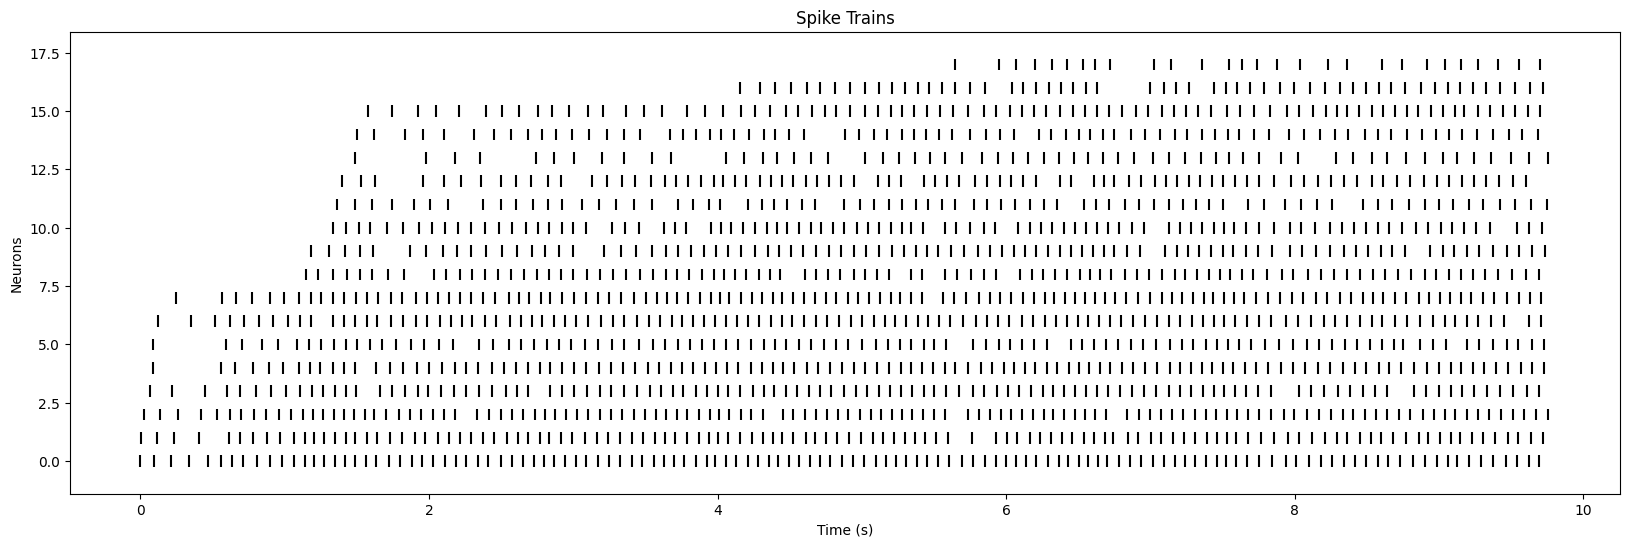

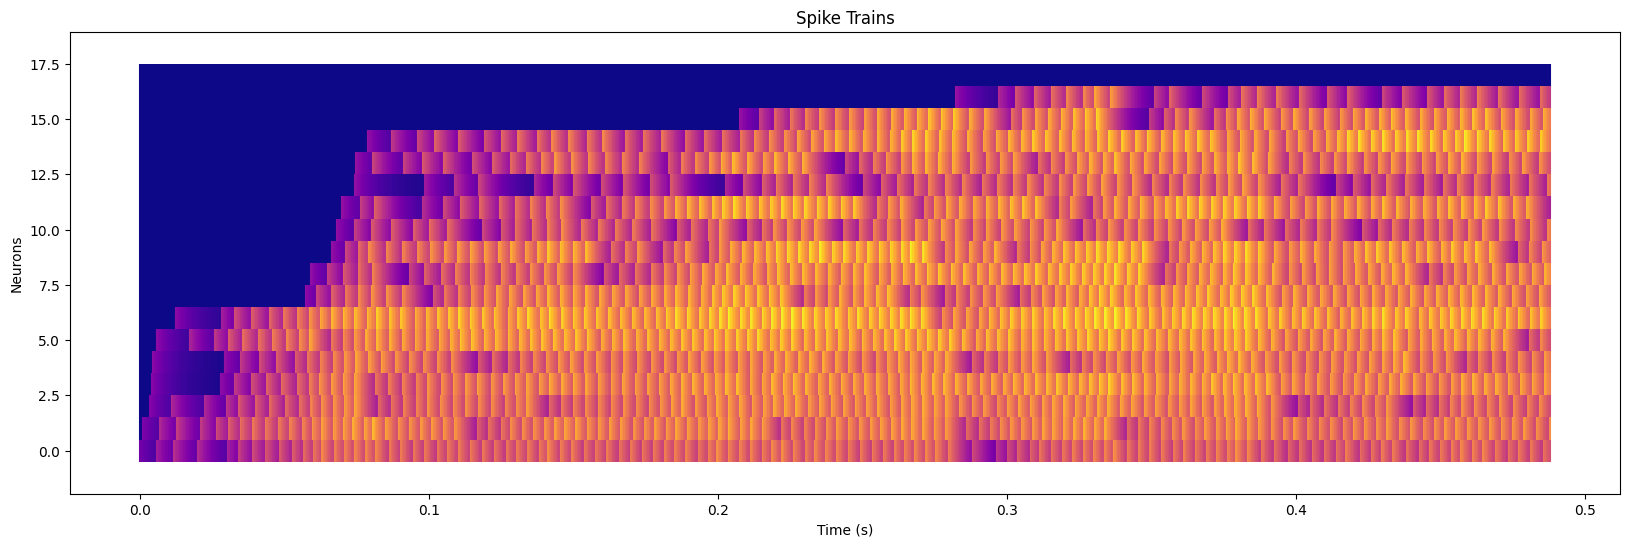

In [212]:
from typing import cast
import numpy as np
from globals.visualization import visualize_trial, visualize_spike_trains
from processing import constants

view_index = 4
binned_section = (0, 1000) # (start, end) in time-steps or None

original_df = df.sample(frac=1, random_state=42).reset_index(drop=True) # shuffle to align with preprocessed data

original_section = cast(tuple[int, int], tuple(x * constants.bin_size for x in binned_section)) if binned_section else None
original_neuron, original_force = original_df.iloc[view_index]["neuron_data"], original_df.iloc[view_index]["force_data"]
preprocessed_neuron, preprocessed_force = preprocessed_df.iloc[view_index]["neuron_data"], preprocessed_df.iloc[view_index]["force_data"]
mvc_level_index = np.where(np.all(preprocessed_neuron == original_df.iloc[view_index]["mvc_level"] / 100, axis=1))[0][0]
visualize_spike_trains(original_neuron, section=original_section, bw=True)
visualize_spike_trains(preprocessed_neuron[:mvc_level_index], section=binned_section, line_height=1)
# visualize_trial(neuron_data=original_neuron, force_data=original_force)
# visualize_trial(neuron_data=original_neuron, force_data=preprocessed_force)

In [217]:
train_gen, val_gen, test_gen = preprocessor.get_generators()

batch = next(train_gen)
batch[0].shape, batch[1].shape

((16, 200, 34), (16, 200))

### Direct Prediction

Directly predict force given neuron data using LSTM neural networks.

In [ ]:
import processing.processing
import prediction.constants
import prediction.dpm
import prediction.metrics

In [ ]:
# train each architecture with all temporal context windows
for size in prediction.constants.architecture_temporal_context_windows.keys():
    context_params = prediction.constants.architecture_temporal_context_windows[size]
    sequence_length, stride = context_params['sequence_length'], context_params['stride']

    # train each architecture with the current context
    for architecture_name in prediction.constants.architecture_names:
        Log.info(f"Training {architecture_name} architecture with {size} context size (sl={sequence_length}, s={stride})")
        processor = processing.processing.Processing(df, sequence_length=sequence_length, stride=stride) # create context-specific processing object
        model = prediction.dpm.DirectPredictionModel(processor=processor, architecture_name=architecture_name, overwrite=False)
        model.optionally_train() # train the model if it hasn't been trained already

In [ ]:
metrics = prediction.metrics.Metrics(reset=False) # get the metrics for each architecture

# compute metrics if they haven't already been computed
if not metrics.exists():
    # get each trained architecture with all temporal context windows
    for size in prediction.constants.architecture_temporal_context_windows.keys():
        context_params = prediction.constants.architecture_temporal_context_windows[size]
        sequence_length, stride = context_params['sequence_length'], context_params['stride']

        # get each trained architecture with the current context
        for architecture_name in prediction.constants.architecture_names:
            processor = processing.processing.Processing(df, sequence_length=sequence_length, stride=stride)
            model = prediction.dpm.DirectPredictionModel(processor=processor, architecture_name=architecture_name, overwrite=False)
            
            # model hasn't been trained -> unable to make predictions -> skip
            if not model.trained:
                continue
            
            metrics.compute_metrics(model)

    metrics.save_metrics()

In [ ]:
metrics.metrics

In [ ]:
metrics.metrics_by_model(export=False)
metrics.metrics_by_mvc(export=False)
metrics.metrics_by_window(export=False)

In [ ]:
metrics.visualize(export=False)

In [ ]:
from prediction import constants
from globals.visualization import visualize_trial
import os

processor = processing.processing.Processing(df, **constants.architecture_temporal_context_windows['large'])
model = prediction.dpm.DirectPredictionModel(processor=processor, architecture_name='single-lstm', overwrite=False)

os.makedirs("prediction/out/predictions", exist_ok=True) # create the output directory if it doesn't exist

# predict for all data and visualize
for index, trial in df.iterrows():
    subject, trial_number, neuron_data, mvc_level = trial['subject'], trial['trial_number'], trial['neuron_data'], trial['mvc_level']
    Log.info(f"Predicting: {subject}.{mvc_level}.{trial_number}")
    predicted_force = model.predict(neuron_data, mvc_level)
    visualize_trial(df, subject=trial['subject'], trial_number=trial['trial_number'], mvc_level=trial['mvc_level'], predicted_force=predicted_force, export_path=f"prediction/out/predictions/{subject}.{mvc_level}.{trial_number}.png")